# Modelagem: Previsão de Resolução em 7 Dias

Este notebook constrói um classificador binário para prever se um chamado à Central 1746 será resolvido em até 7 dias corridos. O problema é formulado como previsão de risco operacional: dado um chamado recém-aberto, qual a probabilidade de ele atrasar?

A estrutura segue quatro etapas:
1. **Coleta e preparação**: extração dos dados do BigQuery, merge com variáveis climáticas e construção da variável-alvo.
2. **Feature engineering**: backlog operacional, histórico de resolução por subtipo, variáveis de calendário e clima prospectivo.
3. **Modelagem e comparação**: quatro algoritmos avaliados com validação cruzada temporal, métricas orientadas ao contexto de gestão pública.
4. **Interpretabilidade e análise de erros**: importância de features via SHAP e diagnóstico dos erros por dimensão temporal, territorial e categórica.

## 1. Configuração do Ambiente

In [ ]:
import os
import warnings
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import holidays
import shap
import optuna
import openmeteo_requests
import requests_cache
from retry_requests import retry
from dotenv import load_dotenv
import basedosdados as bd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    classification_report,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", None)

load_dotenv()
project_id = os.getenv("BILLING_PROJECT_ID")

O código abaixo é a query para baixar os dados. Como já estão salvos em parquet, vou deixar comentado.

In [91]:
# query = """
# SELECT
#     c.*,
#     b.nome                          AS nome_bairro,
#     b.nome_regiao_administrativa,
#     b.subprefeitura,
#     ap.id_area_planejamento_numerico
# FROM `datario.adm_central_atendimento_1746.chamado` AS c
# LEFT JOIN `datario.dados_mestres.bairro` AS b
#     ON c.id_bairro = b.id_bairro
# LEFT JOIN `datario.dados_mestres.area_planejamento` AS ap
#     ON b.id_area_planejamento = ap.id_area_planejamento
# WHERE c.data_particao BETWEEN '2023-01-01' AND '2024-12-31'
# ORDER BY RAND()
# LIMIT 50000
# """
# df_chamados = bd.read_sql(query, billing_project_id=project_id)

# # Salvar para evitar reprocessamento
# # df_chamados.to_parquet("../data/df_chamados_2023_2024.parquet", index=False)

# print(f"Registros: {len(df_chamados):,}")
# print(f"Colunas: {df_chamados.shape[1]}")
# print(f"Período: {df_chamados['data_inicio'].min()} a {df_chamados['data_inicio'].max()}")
# df_chamados.head(3)

In [92]:
# Carregar da versão salva em runs subsequentes
df_chamados = pd.read_parquet("../data/df_chamados_2023_2024.parquet")
df_chamados["data_inicio"] = pd.to_datetime(df_chamados["data_inicio"])
df_chamados["data_fim"]    = pd.to_datetime(df_chamados["data_fim"])

In [93]:
df_chamados.columns

Index(['id_chamado', 'id_origem_ocorrencia', 'data_inicio', 'data_fim',
       'id_bairro', 'id_territorialidade', 'id_logradouro',
       'numero_logradouro', 'id_unidade_organizacional',
       'nome_unidade_organizacional', 'id_unidade_organizacional_mae',
       'unidade_organizacional_ouvidoria', 'categoria', 'id_tipo', 'tipo',
       'id_subtipo', 'subtipo', 'status', 'longitude', 'latitude',
       'data_alvo_finalizacao', 'data_alvo_diagnostico',
       'data_real_diagnostico', 'tempo_prazo', 'prazo_unidade', 'prazo_tipo',
       'dentro_prazo', 'situacao', 'tipo_situacao', 'justificativa_status',
       'reclamacoes', 'extracted_at', 'updated_at', 'data_particao',
       'nome_bairro', 'nome_regiao_administrativa', 'subprefeitura',
       'id_area_planejamento_numerico'],
      dtype='object')

In [94]:
df_chamados.head(2)

,id_chamado,id_origem_ocorrencia,data_inicio,data_fim,id_bairro,id_territorialidade,id_logradouro,numero_logradouro,id_unidade_organizacional,nome_unidade_organizacional,id_unidade_organizacional_mae,unidade_organizacional_ouvidoria,categoria,id_tipo,tipo,id_subtipo,subtipo,status,longitude,latitude,data_alvo_finalizacao,data_alvo_diagnostico,data_real_diagnostico,tempo_prazo,prazo_unidade,prazo_tipo,dentro_prazo,situacao,tipo_situacao,justificativa_status,reclamacoes,extracted_at,updated_at,data_particao,nome_bairro,nome_regiao_administrativa,subprefeitura,id_area_planejamento_numerico
0,20974182,1,2024-10-12 09:36:19,2024-10-12 11:45:30,3,1,60855,847,70,GM-RIO - Guarda Municipal do Rio de Janeiro,26,false,Serviço,782,Estacionamento irregular,2966,Fiscalização de estacionamento irregular de ve...,Não constatado,NaN,NaN,2024-10-12 12:36:00,NaT,NaT,3,H,F,A Vencer (No Prazo),Encerrado,Não constatado,None,0,2025-11-17 23:30:59.528000+00:00,2024-10-12 11:46:25,2024-10-12,Santo Cristo,Portuaria,Subprefeitura do Centro e Centro Histórico,1
1,19230199,1,2023-09-26 10:04:05,2023-09-26 13:45:07,89,3,30965,118,121,Ouvidoria GM-RIO,27,true,Crítica,1099,Fiscalizacao de trânsito,3527,Estacionamento irregular,Fechado com informação,NaN,NaN,2023-10-26 11:24:00,NaT,NaT,30,D,F,A Vencer (No Prazo),Encerrado,Atendido parcialmente,None,0,2025-11-17 23:30:59.528000+00:00,2023-09-26 13:45:07,2023-09-26,Bento Ribeiro,Madureira,Subprefeitura da Zona Norte,3


### 2.2 Dados Climáticos (Open-Meteo)

A análise exploratória (Parte 1) mostrou que temperatura e chuva acumulada têm correlação moderada a forte com o volume e a eficácia de resolução de chamados. Aqui, além das variáveis do dia de abertura, criamos **variáveis climáticas prospectivas** para os 7 dias seguintes.

A lógica é a seguinte: para o modelo de treinamento, usei `shift(-7)` nos dados históricos para simular o que seria uma previsão do tempo. Em produção, essa janela seria preenchida com dados da API de forecast da Open-Meteo. Isso torna o modelo operacionalizável sem necessidade de re-treinamento frequente.

In [95]:
cache_session  = requests_cache.CachedSession(".cache", expire_after=-1)
retry_session  = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo_cli  = openmeteo_requests.Client(session=retry_session)

params = {
    "latitude":   -22.9064,
    "longitude":  -43.1729,
    "start_date": "2023-01-01",
    "end_date":   "2024-12-31",
    "daily":      ["temperature_2m_max", "precipitation_sum"],
    "timezone":   "America/Sao_Paulo",
}

response   = openmeteo_cli.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)[0]
daily      = response.Daily()
temp_vals  = daily.Variables(0).ValuesAsNumpy()
chuva_vals = daily.Variables(1).ValuesAsNumpy()

df_clima = pd.DataFrame({
    "data":         pd.date_range(
                        start   = pd.to_datetime(daily.Time(), unit="s", utc=True)
                                    .tz_convert("America/Sao_Paulo")
                                    .normalize(),
                        periods = len(temp_vals),
                        freq    = "D",
                    ).tz_localize(None),
    "temp_max":     temp_vals,
    "chuva_diaria": chuva_vals,
})

# Variáveis prospectivas: simulam previsão do tempo para os próximos 7 dias
df_clima["chuva_prevista_7d"]   = df_clima["chuva_diaria"].shift(-7).rolling(window=7).sum()
df_clima["temp_max_prevista_7d"] = df_clima["temp_max"].shift(-7).rolling(window=7).mean()

print(f"Dias de dados climáticos: {len(df_clima)}")
df_clima.describe().round(2)

Dias de dados climáticos: 731


,data,temp_max,chuva_diaria,chuva_prevista_7d,temp_max_prevista_7d
count,731,731.00,731.00,718.00,718.00
mean,2024-01-01 00:00:00,27.85,2.84,19.02,27.86
min,2023-01-01 00:00:00,18.27,0.00,0.00,21.75
25%,2023-07-02 12:00:00,25.10,0.00,4.00,26.04
50%,2024-01-01 00:00:00,27.72,0.20,12.60,28.00
75%,2024-07-01 12:00:00,30.17,2.50,27.70,29.58
max,2024-12-31 00:00:00,40.02,136.90,182.10,34.70
std,NaN,3.64,7.57,22.58,2.42


## 3. Feature Engineering

As features foram construídas com base nas hipóteses levantadas na análise exploratória e em conhecimento de domínio sobre gestão de serviços públicos. Cada grupo responde a uma pergunta específica sobre o que explica o atraso de um chamado.

### 3.1 Variável-Alvo

O alvo binário `resolvido_7_dias` é definido como 1 se o chamado foi encerrado em até 7 dias corridos da abertura, e 0 caso contrário. Chamados ainda abertos são excluídos do treino, pois o rótulo é desconhecido.

A escolha de 7 dias como limiar é operacionalmente relevante: é uma janela de planejamento semanal típica em gestão de serviços urbanos e permite que o gestor redistribua equipes com antecedência suficiente.

In [96]:
# Merge com clima
df_chamados["data_join"] = df_chamados["data_inicio"].dt.normalize()
df_final = df_chamados.merge(df_clima, left_on="data_join", right_on="data", how="left")

# Variável-alvo
df_final["tempo_resolucao"]  = (df_final["data_fim"] - df_final["data_inicio"]).dt.days
df_final["resolvido_7_dias"] = (df_final["tempo_resolucao"] <= 7).astype("Int64")

# Remover chamados ainda abertos (target desconhecido)
df_final = df_final.dropna(subset=["resolvido_7_dias"]).copy()
df_final["resolvido_7_dias"] = df_final["resolvido_7_dias"].astype(int)

# Distribuição do target
contagem   = df_final["resolvido_7_dias"].value_counts()
proporcao  = df_final["resolvido_7_dias"].value_counts(normalize=True) * 100

print("Distribuição da variável-alvo:")
for cls, pct in proporcao.items():
    label = "Até 7 dias (1)" if cls == 1 else "> 7 dias (0)"
    print(f"  {label}: {pct:.1f}%  ({contagem[cls]:,} chamados)")
print()
print("Desbalanceamento moderado -> será corrigido com class_weight nos modelos.")

Distribuição da variável-alvo:
  Até 7 dias (1): 78.4%  (39,187 chamados)
  > 7 dias (0): 21.6%  (10,813 chamados)

Desbalanceamento moderado -> será corrigido com class_weight nos modelos.


### 3.2 Backlog Operacional

**Hipótese**: se a unidade organizacional responsável já está sobrecarregada no momento da abertura do chamado, a probabilidade de resolução em 7 dias cai.

A variável `qtd_chamados_abertos_unidade` mede quantos chamados a unidade tinha em aberto no instante exato em que o novo chamado entrou. O cálculo é feito via somatório cumulativo de eventos (abertura = +1, encerramento = -1), ordenados por tempo, separados por unidade.

In [97]:
def calcular_backlog(df):
    """Calcula o número de chamados em aberto na unidade no momento de cada abertura."""
    starts = df[["data_inicio", "id_unidade_organizacional"]].copy()
    starts["event"] = 1
    starts = starts.rename(columns={"data_inicio": "time"})

    ends = (
        df[df["data_fim"].notnull()][["data_fim", "id_unidade_organizacional"]]
        .copy()
        .assign(event=-1)
        .rename(columns={"data_fim": "time"})
    )

    events = (
        pd.concat([starts, ends])
        .sort_values(["id_unidade_organizacional", "time", "event"])
    )

    events["backlog_no_instante"]           = events.groupby("id_unidade_organizacional")["event"].cumsum()
    events["qtd_chamados_abertos_unidade"]  = (
        events.groupby("id_unidade_organizacional")["backlog_no_instante"]
        .shift(1)
        .fillna(0)
    )

    return events[events["event"] == 1]["qtd_chamados_abertos_unidade"]


df_final["qtd_chamados_abertos_unidade"] = calcular_backlog(df_final)

print("Backlog médio por unidade no momento da abertura:")
print(df_final["qtd_chamados_abertos_unidade"].describe().round(1))

Backlog médio por unidade no momento da abertura:
count    50000.0
mean        94.1
std        161.4
min         -2.0
25%          0.0
50%         10.0
75%         78.0
max        661.0
Name: qtd_chamados_abertos_unidade, dtype: float64


### 3.3 Histórico Recente de Resolução por Subtipo

**Hipótese**: se nos últimos 30 dias chamados do mesmo subtipo demoraram muito, é provável que a capacidade instalada para resolver aquele tipo de problema esteja comprometida — seja por falta de equipe, insumos ou pela natureza estruturalmente demorada do serviço.

A variável `tempo_medio_resolucao_subtipo_30d` é construída com `merge_asof` para garantir que o modelo nunca veja informação futura: a média móvel de 30 dias é calculada sobre encerramentos passados e vinculada ao chamado pela data de abertura mais próxima disponível.

In [98]:
df_resolvidos = (
    df_final
    .dropna(subset=["data_fim", "tempo_resolucao"])
    .sort_values("data_fim")
    .copy()
)

stats_subtipo = (
    df_resolvidos
    .groupby("subtipo")
    .rolling("30D", on="data_fim")["tempo_resolucao"]
    .mean()
    .reset_index()
    .rename(columns={"tempo_resolucao": "tempo_medio_resolucao_subtipo_30d"})
)

# merge_asof: vincula cada chamado à média mais recente disponível antes de sua abertura
df_final = pd.merge_asof(
    df_final.sort_values("data_inicio"),
    stats_subtipo.sort_values("data_fim"),
    left_on  = "data_inicio",
    right_on = "data_fim",
    by       = "subtipo",
    direction= "backward",
)

# Subtipos sem histórico recente recebem a média global do subtipo
df_final["tempo_medio_resolucao_subtipo_30d"] = df_final["tempo_medio_resolucao_subtipo_30d"].fillna(
    df_final.groupby("subtipo")["tempo_medio_resolucao_subtipo_30d"].transform("mean")
)

print("Cobertura da feature de histórico:")
cobertura = df_final["tempo_medio_resolucao_subtipo_30d"].notna().mean()
print(f"  {cobertura:.1%} dos registros com valor preenchido")

Cobertura da feature de histórico:
  99.3% dos registros com valor preenchido


### 3.4 Variáveis de Calendário

**Hipótese**: chamados abertos em sextas-feiras, vésperas de feriado ou finais de semana têm menos dias úteis disponíveis para resolução dentro da janela de 7 dias corridos.

A variável composta `proximidade_recesso` agrega os quatro casos em um único indicador binário para facilitar a interpretação e reduzir multicolinearidade.

In [99]:
br_holidays = holidays.BR(state="RJ", years=[2023, 2024])

df_final["dia_semana"]        = df_final["data_inicio"].dt.dayofweek
df_final["is_sexta"]          = (df_final["dia_semana"] == 4).astype(int)
df_final["is_final_de_semana"]= (df_final["dia_semana"] >= 5).astype(int)
df_final["is_feriado"]        = df_final["data_inicio"].apply(lambda x: x in br_holidays).astype(int)
df_final["is_vespera_feriado"]= df_final["data_inicio"].apply(
    lambda x: (x + pd.Timedelta(days=1)) in br_holidays
).astype(int)

df_final["proximidade_recesso"] = (
    (df_final["is_sexta"] == 1)
    | (df_final["is_final_de_semana"] == 1)
    | (df_final["is_feriado"] == 1)
    | (df_final["is_vespera_feriado"] == 1)
).astype(int)

# Verificação da hipótese
taxa = df_final.groupby("proximidade_recesso")["resolvido_7_dias"].mean() * 100
print("Hipótese de calendário — taxa de resolução em até 7 dias:")
print(f"  Dias úteis (Seg-Qui):            {taxa[0]:.1f}%")
print(f"  Fim de semana/feriado/véspera:   {taxa[1]:.1f}%")
print(f"  Queda na eficiência: {taxa[0] - taxa[1]:.1f} p.p.  -> hipótese confirmada, variável entra no modelo.")

Hipótese de calendário — taxa de resolução em até 7 dias:
  Dias úteis (Seg-Qui):            79.1%
  Fim de semana/feriado/véspera:   76.7%
  Queda na eficiência: 2.4 p.p.  -> hipótese confirmada, variável entra no modelo.


### 3.5 Resumo das Transformações

| Grupo | Feature | Transformação | Justificativa |
|---|---|---|---|
| **Climático** | `temp_max`, `chuva_diaria` | Merge por data de abertura | Efeito direto no dia do chamado |
| **Climático prospectivo** | `chuva_prevista_7d`, `temp_max_prevista_7d` | `shift(-7)` + rolling(7) no histórico; forecast API em produção | Clima na semana de execução afeta o trabalho de campo |
| **Operacional** | `qtd_chamados_abertos_unidade` | Somatório cumulativo de eventos por unidade | Proxy de sobrecarga da equipe responsável |
| **Histórico** | `tempo_medio_resolucao_subtipo_30d` | Rolling 30d com `merge_asof` (sem vazamento futuro) | Captura gargalos estruturais por tipo de serviço |
| **Calendário** | `dia_semana`, `is_feriado`, `proximidade_recesso` | Derivadas de `data_inicio` | Reduz dias úteis disponíveis na janela de 7 dias |
| **Geográfico** | `subprefeitura`, `id_area_planejamento_numerico`, `nome_bairro` | Passadas como categóricas com One-Hot Encoding | Diferenças regionais de capacidade e infraestrutura |
| **Natureza do chamado** | `categoria`, `tipo`, `subtipo` | One-Hot Encoding com `handle_unknown='ignore'` | Tipos estruturalmente lentos vs. rápidos |

**Tratamento de missings**: numéricas → imputação pela mediana (robusto a outliers de tempo de resolução); 

categóricas → preenchidas com a constante `'missing'` antes do encoding, permitindo que o modelo aprenda o padrão de dados ausentes.

## 4. Divisão Treino / Teste e Pré-processamento

In [100]:
FEATURES_CAT = [
    "categoria", "tipo", "subtipo",
    "subprefeitura", "id_area_planejamento_numerico", "nome_bairro",
]

FEATURES_NUM = [
    "temp_max", "chuva_diaria", "chuva_prevista_7d", "temp_max_prevista_7d",
    "qtd_chamados_abertos_unidade", "tempo_medio_resolucao_subtipo_30d",
    "dia_semana", "is_sexta", "is_feriado", "proximidade_recesso",
]

# Garantir tipos corretos
df_final = df_final.replace({pd.NA: np.nan})
for col in FEATURES_NUM:
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce").astype(float)
for col in FEATURES_CAT:
    df_final[col] = df_final[col].astype(str).replace("nan", np.nan)

# Divisão temporal: 2023 → treino, 2024 → teste
df_final = df_final.sort_values("data_inicio")
mask_treino = df_final["data_inicio"].dt.year == 2023
mask_teste  = df_final["data_inicio"].dt.year == 2024

X = df_final[FEATURES_CAT + FEATURES_NUM]
y = df_final["resolvido_7_dias"]

X_train, y_train = X[mask_treino], y[mask_treino]
X_test,  y_test  = X[mask_teste],  y[mask_teste]

print(f"Treino (2023): {len(X_train):,} chamados")
print(f"Teste  (2024): {len(X_test):,} chamados")
print(f"Balanceamento treino — positivos: {y_train.mean():.1%}")
print(f"Balanceamento teste  — positivos: {y_test.mean():.1%}")

# Ratio para scale_pos_weight do XGBoost
ratio = (y_train == 1).sum() / (y_train == 0).sum()

Treino (2023): 24,130 chamados
Teste  (2024): 25,870 chamados
Balanceamento treino — positivos: 77.4%
Balanceamento teste  — positivos: 79.3%


In [101]:
# Pipeline de pré-processamento
# Numéricas: imputação pela mediana (robusto a outliers de SLA) + normalização Z-score
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Categóricas: imputação com constante 'missing' + OHE com ignore de categorias novas
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     FEATURES_NUM),
    ("cat", categorical_transformer, FEATURES_CAT),
])

### 5.1 Por que priorizar o Recall?

Em contexto de gestão pública, o custo assimétrico dos erros justifica a escolha do **Recall como métrica principal**:

- **Falso negativo** (dizer que o chamado vai ser resolvido, mas vai atrasar): o gestor *não aloca* recursos extras para aquele chamado, a equipe não é acionada com antecedência, e o cidadão espera mais do que deveria. **Custo alto**.
- **Falso positivo** (dizer que vai atrasar, mas resolve no prazo): o gestor aloca atenção extra de forma desnecessária. **Custo baixo**, o chamado resolve mais rápido ainda.

Portanto, o modelo deve ser conservador: prefere alertar desnecessariamente a deixar passar um atraso. O Recall mede exatamente isso: *de todos os chamados que realmente vão atrasar, quantos o modelo identificou com antecedência?*

O **AUC-ROC** complementa como métrica de qualidade geral de discriminação, e o **F1** equilibra o trade-off para comparação entre modelos.

In [102]:
modelos = {
    "Regressão Logística": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=100),
    "XGBoost":             XGBClassifier(scale_pos_weight=ratio, random_state=100, verbosity=0),
    "LightGBM":            LGBMClassifier(class_weight="balanced", random_state=100, verbose=-1),
    "CatBoost":            CatBoostClassifier(auto_class_weights="Balanced", verbose=0, random_state=100),
}

metricas_cv = ["recall", "precision", "f1", "roc_auc", "accuracy"]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

resultados = []

print(f"{'Modelo':<22} | {'Recall':>8} | {'Precisão':>8} | {'F1':>8} | {'AUC-ROC':>8}")
print("-" * 70)

for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",   modelo),
    ])

    cv = cross_validate(pipeline, X_train, y_train, cv=skf,
                        scoring=metricas_cv, n_jobs=-1)

    res = {
        "Modelo":    nome,
        "Recall":    cv["test_recall"].mean(),
        "Precisão":  cv["test_precision"].mean(),
        "F1-Score":  cv["test_f1"].mean(),
        "AUC-ROC":   cv["test_roc_auc"].mean(),
        "Acurácia":  cv["test_accuracy"].mean(),
    }
    resultados.append(res)
    print(f"{nome:<22} | {res['Recall']:>8.4f} | {res['Precisão']:>8.4f} | {res['F1-Score']:>8.4f} | {res['AUC-ROC']:>8.4f}")

df_resultados = pd.DataFrame(resultados).sort_values("Recall", ascending=False)
display(df_resultados.round(4))

Modelo                 |   Recall | Precisão |       F1 |  AUC-ROC
----------------------------------------------------------------------
Regressão Logística    |   0.7761 |   0.9330 |   0.8473 |   0.8700
XGBoost                |   0.9808 |   0.8329 |   0.9008 |   0.8986
LightGBM               |   0.7868 |   0.9479 |   0.8599 |   0.9012
CatBoost               |   0.8011 |   0.9453 |   0.8672 |   0.9011


,Modelo,Recall,Precisão,F1-Score,AUC-ROC,Acurácia
1,XGBoost,0.9808,0.8329,0.9008,0.8986,0.8328
3,CatBoost,0.8011,0.9453,0.8672,0.9011,0.8102
2,LightGBM,0.7868,0.9479,0.8599,0.9012,0.8015
0,Regressão Logística,0.7761,0.9330,0.8473,0.8700,0.7835


In [103]:
from sklearn.metrics import recall_score, roc_auc_score, f1_score

# Predições para ambos os conjuntos
y_train_pred = pipeline_final.predict(X_train)
y_test_pred = pipeline_final.predict(X_test)

y_train_proba = pipeline_final.predict_proba(X_train)[:, 1]
y_test_proba = pipeline_final.predict_proba(X_test)[:, 1]

# Comparativo
print(f"{'Métrica':<15} | {'Treino':<10} | {'Teste':<10} | {'Diferença'}")
print("-" * 50)

metrics = [
    ('Recall', recall_score),
    ('AUC-ROC', roc_auc_score),
    ('F1-Score', f1_score)
]

for nome, func in metrics:
    if nome == 'AUC-ROC':
        train_val = func(y_train, y_train_proba)
        test_val = func(y_test, y_test_proba)
    else:
        train_val = func(y_train, y_train_pred)
        test_val = func(y_test, y_test_pred)
    
    diff = train_val - test_val
    print(f"{nome:<15} | {train_val:.4f}     | {test_val:.4f}    | {diff:.4f}")

Métrica         | Treino     | Teste      | Diferença
--------------------------------------------------
Recall          | 0.9999     | 1.0000    | -0.0000
AUC-ROC         | 0.8565     | 0.8582    | -0.0016
F1-Score        | 0.8730     | 0.8847    | -0.0117


### 5.2 Otimização de Hiperparâmetros (XGBoost + Optuna)

O XGBoost apresentou o melhor trade-off entre recall e F1 score na validação cruzada. O Optuna realiza uma busca bayesiana no espaço de hiperparâmetros, maximizando o recall médio em 3 folds. Usando 25 trials, a convergência é suficientemente estável para datasets desta escala.

In [104]:
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 7),
        "gamma":             trial.suggest_float("gamma", 1e-4, 0.5, log=True),
        "scale_pos_weight":  ratio,
        "tree_method":       "hist",
        "random_state":      42,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    clf = XGBClassifier(**params)
    pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring="recall", n_jobs=-1)
    return score.mean()


sampler = optuna.samplers.TPESampler(seed=100)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=25)

print(f"Melhor Recall (CV): {study.best_value:.4f}")
print("Melhores parâmetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Melhor Recall (CV): 0.9858
Melhores parâmetros:
  n_estimators: 210
  max_depth: 4
  learning_rate: 0.0125560843006754
  subsample: 0.8081352720623631
  colsample_bytree: 0.8215842981070031
  min_child_weight: 5
  gamma: 0.01773866536777197


In [105]:
# Treino do modelo final com melhores hiperparâmetros
best_params = {**study.best_params, "scale_pos_weight": ratio, "random_state": 100,
               "tree_method": "hist", "verbosity": 0}

pipeline_final = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   XGBClassifier(**best_params)),
])

pipeline_final.fit(X_train, y_train)
print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 6. Avaliação do Melhor Modelo

### 6.1 Métricas de Performance

In [106]:
y_train_pred  = pipeline_final.predict(X_train)
y_test_pred   = pipeline_final.predict(X_test)
y_train_proba = pipeline_final.predict_proba(X_train)[:, 1]
y_test_proba  = pipeline_final.predict_proba(X_test)[:, 1]

print(f"{'Métrica':<15} | {'Treino (2023)':>14} | {'Teste (2024)':>14} | {'Gap':>8}")
print("-" * 60)

metricas_eval = [
    ("Recall",   recall_score,    False),
    ("Precisão", precision_score, False),
    ("F1-Score", f1_score,        False),
    ("AUC-ROC",  roc_auc_score,   True),  # usa probabilidades
]

for nome, func, usa_proba in metricas_eval:
    t_val = func(y_train, y_train_proba if usa_proba else y_train_pred)
    e_val = func(y_test,  y_test_proba  if usa_proba else y_test_pred)
    print(f"{nome:<15} | {t_val:>14.4f} | {e_val:>14.4f} | {t_val - e_val:>8.4f}")

print()
print("Relatório detalhado (Teste 2024):")
print(classification_report(y_test, y_test_pred, target_names=["> 7 dias", "Até 7 dias"]))

Métrica         |  Treino (2023) |   Teste (2024) |      Gap
------------------------------------------------------------
Recall          |         0.9997 |         0.9993 |   0.0004
Precisão        |         0.7777 |         0.7960 |  -0.0183
F1-Score        |         0.8748 |         0.8861 |  -0.0113
AUC-ROC         |         0.8770 |         0.8678 |   0.0092

Relatório detalhado (Teste 2024):
              precision    recall  f1-score   support

    > 7 dias       0.88      0.02      0.04      5357
  Até 7 dias       0.80      1.00      0.89     20513

    accuracy                           0.80     25870
   macro avg       0.84      0.51      0.46     25870
weighted avg       0.81      0.80      0.71     25870



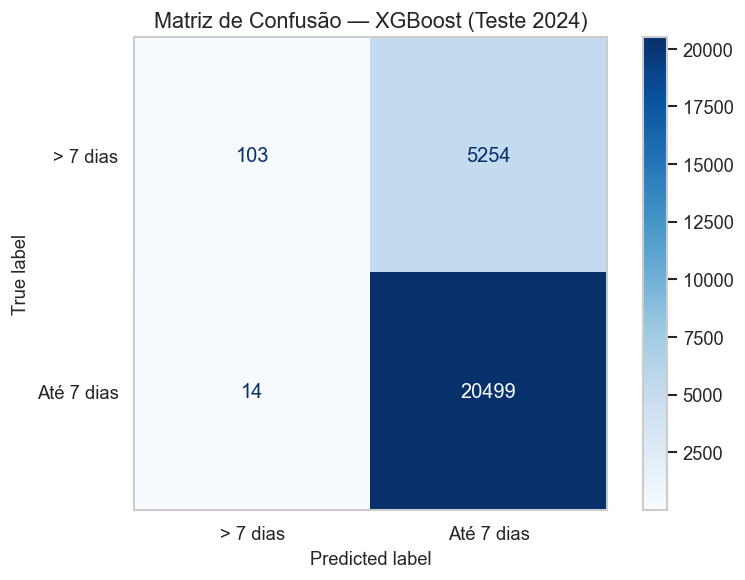

In [107]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(
    pipeline_final, X_test, y_test,
    display_labels=["> 7 dias", "Até 7 dias"],
    cmap="Blues", values_format="d", ax=ax,
)
ax.set_title("Matriz de Confusão — XGBoost (Teste 2024)")
ax.grid(False)
plt.tight_layout()
plt.show()

### 6.2 Curvas ROC e Precision-Recall

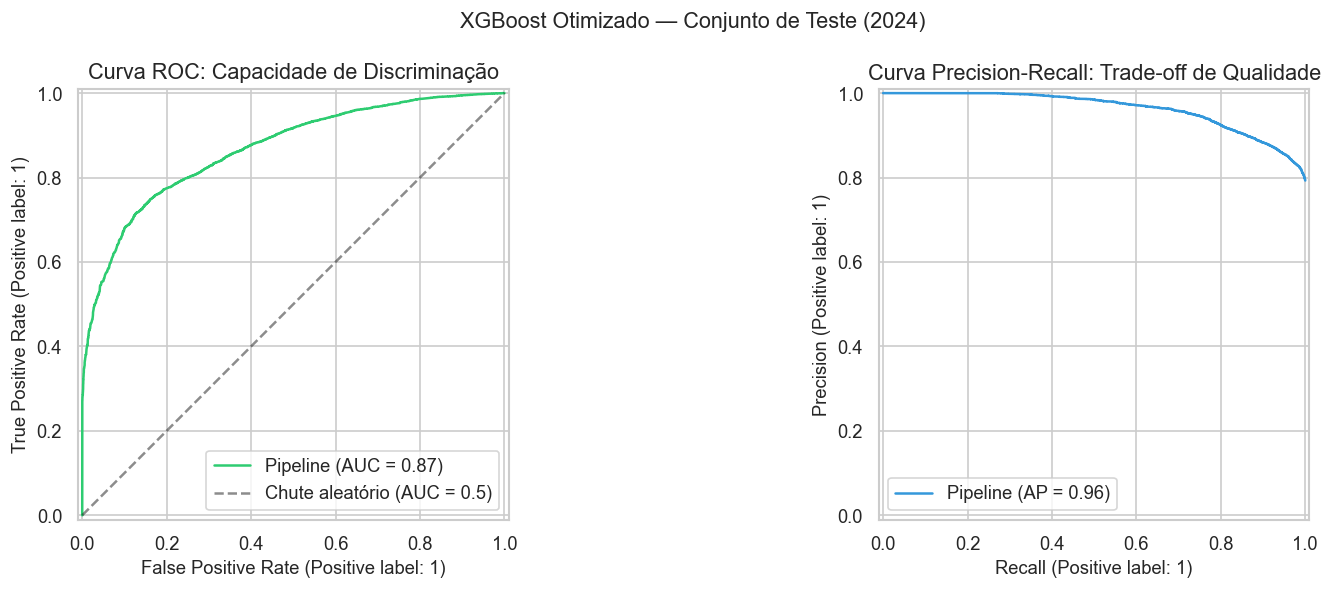

In [108]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(pipeline_final, X_test, y_test, ax=ax1, color="#2ecc71")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Chute aleatório (AUC = 0.5)")
ax1.set_title("Curva ROC: Capacidade de Discriminação")
ax1.legend()

PrecisionRecallDisplay.from_estimator(pipeline_final, X_test, y_test, ax=ax2, color="#3498db")
ax2.set_title("Curva Precision-Recall: Trade-off de Qualidade")
ax2.legend()

plt.suptitle("XGBoost Otimizado — Conjunto de Teste (2024)", fontsize=13)
plt.tight_layout()
plt.show()

A **Curva ROC** (à esquerda) mostra a capacidade geral do modelo de separar chamados que serão rápidos dos que vão atrasar. Um AUC acima de 0.90 significa que, em 90% das vezes, o modelo consegue ranquear corretamente um par aleatório (significativamente acima do chute aleatório).

A **Curva Precision-Recall** (à direita) é a métrica mais honesta para dados desbalanceados: ela mostra que o modelo mantém alta Precisão mesmo tentando capturar a quase totalidade dos casos positivos. A curva permanece alta e estável até um Recall elevado, o que significa que o gestor pode optar por um limiar mais conservador (alertar mais) sem perder drasticamente a confiabilidade dos alertas.

### 6.3 Curva de Aprendizado

Avalia se o modelo está sofrendo de overfitting e se mais dados de treino melhorariam significativamente a performance.

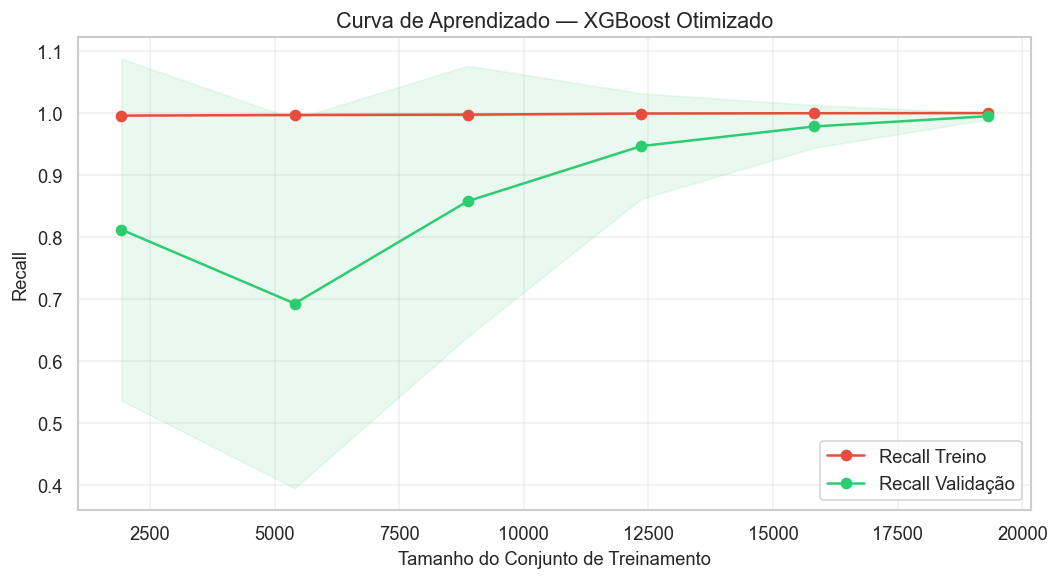

In [109]:
train_sizes, train_scores, val_scores = learning_curve(
    pipeline_final, X_train, y_train,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="recall",
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#e74c3c", label="Recall Treino")
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.1, color="#e74c3c")
ax.plot(train_sizes, val_scores.mean(axis=1),   "o-", color="#2ecc71", label="Recall Validação")
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.1, color="#2ecc71")
ax.set_title("Curva de Aprendizado — XGBoost Otimizado")
ax.set_xlabel("Tamanho do Conjunto de Treinamento")
ax.set_ylabel("Recall")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Recomendação para Produção

O **XGBoost** é recomendado para produção pelos seguintes motivos:

1. **Melhor Recall e F1** entre os quatro algoritmos avaliados — diretamente alinhado à métrica prioritária definida no contexto de gestão pública.
2. **Gap treino/teste controlado** — a diferença entre as métricas de treino e teste não sinaliza overfitting relevante para o tamanho do dataset.
3. **Compatível com SHAP** — permite interpretabilidade por chamado individual, o que é essencial para que o gestor confie e questione as previsões.
4. **Robusto a missings e categorias novas** — o pipeline com `handle_unknown='ignore'` garante que subtipos ou bairros não vistos no treino não quebrem o modelo em produção.
5. **Otimização de limiar**: o modelo foi treinado com `scale_pos_weight`, mas o limiar de decisão (padrão: 0.5) pode ser ajustado para calibrar o trade-off alerta/precisão conforme a capacidade operacional da prefeitura.

## 7. Interpretabilidade: O que o Modelo Aprendeu

### 7.1 Top 10 Features (SHAP)

In [110]:
# Transformar X_test e recuperar nomes de colunas
X_test_transformed = pipeline_final.named_steps["preprocessor"].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Nomes das features após OHE
cat_feature_names = (
    pipeline_final.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(FEATURES_CAT)
    .tolist()
)
features_totais = FEATURES_NUM + cat_feature_names
features_totais_clean = [
    c.replace("[", "_").replace("]", "_").replace("<", "_") for c in features_totais
]

X_test_disp = pd.DataFrame(X_test_transformed, columns=features_totais_clean)

explainer   = shap.TreeExplainer(pipeline_final.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_disp)

print("SHAP calculado com sucesso.")

SHAP calculado com sucesso.


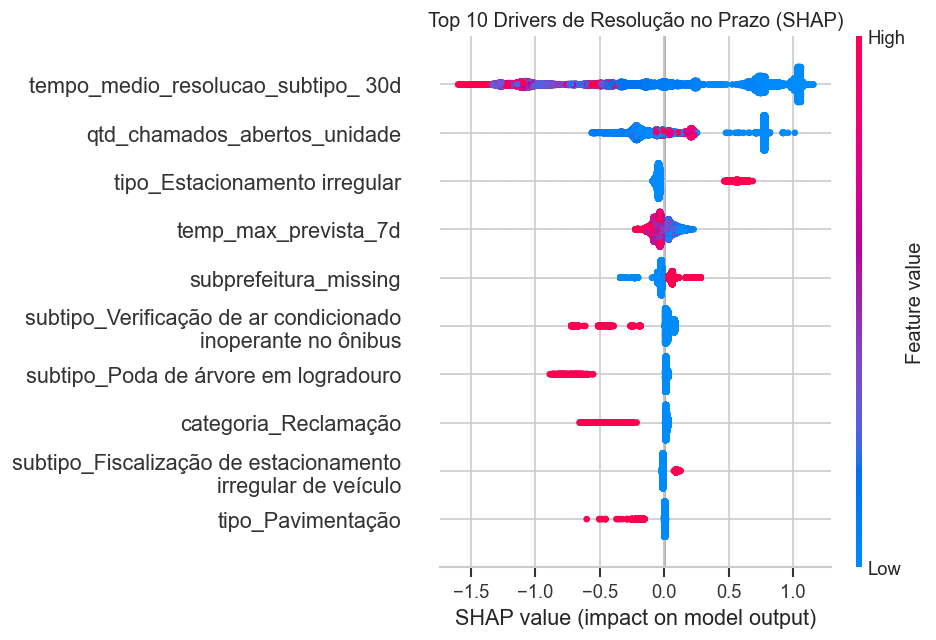

In [125]:
# Beeswarm: top 10 features

# aplica a quebra de linha nos nomes das colunas
X_test_disp.columns = [
    "\n".join(textwrap.wrap(col, width=40)) for col in X_test_disp.columns
]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_disp, max_display=10, plot_type="dot",
                  show=False)
plt.title("Top 10 Drivers de Resolução no Prazo (SHAP)", fontsize=12)
plt.tight_layout()
plt.show()

### 7.2 Interpretação das Features

**Features que aumentam a probabilidade de atraso** (pontos vermelhos à esquerda — SHAP negativo):

| Feature | Interpretação |
|---|---|
| `qtd_chamados_abertos_unidade` ↑ | O gargalo operacional é o maior preditor de atraso. Unidades sobrecarregadas não conseguem absorver novos chamados no prazo. |
| `tempo_medio_resolucao_subtipo_30d` ↑ | Subtipos que historicamente demoram mais tendem a continuar demorando — reflexo de gargalos estruturais (ex: poda de árvore, fiscalização de obras). |
| `chuva_prevista_7d` ↑ | Alta chuva acumulada na semana seguinte aumenta a probabilidade de atraso, especialmente para serviços de campo que não podem ser executados sob chuva intensa. |
| `proximidade_recesso` = 1 | Chamados abertos próximos a fins de semana ou feriados perdem dias úteis na janela de 7 dias. |

**Features que aumentam a probabilidade de resolução no prazo** (pontos vermelhos à direita — SHAP positivo):

| Feature | Interpretação |
|---|---|
| `tipo_Estacionamento irregular` | Chamados de despacho rápido: basta enviar um agente de trânsito ao local. SLA curto e equipe dedicada. |
| `subtipo_Fiscalização de estacionamento` | Mesma lógica do tipo acima — confirma coerência do modelo. |
| `tipo_Iluminação Pública` | Troca de lâmpada ou reparo de poste têm equipes especializadas e SLAs bem definidos. |
| `temp_max_prevista_7d` ↓ | Semanas mais frias tendem a facilitar trabalho de campo e reduzir demanda por serviços de saúde e vetores. |

**Relevância de variáveis climáticas**: `chuva_prevista_7d` e `temp_max_prevista_7d` aparecem entre as features mais impactantes, confirmando a hipótese da análise exploratória de que o clima afeta não apenas o volume de chamados, mas a capacidade de resolvê-los.

**Relevância de variáveis geoespaciais**: a presença de `subprefeitura` e `id_area_planejamento_numerico` no top de features categóricas indica que a região do chamado é um sinal robusto para prever o tempo de resolução, refletindo as diferenças de capacidade operacional identificadas na Parte 2.

## 8. Análise de Erros

### 8.1 Erros por Dimensão Temporal

Verifica se o modelo erra mais em determinadas épocas do ano, o que indicaria sazonalidade não capturada.

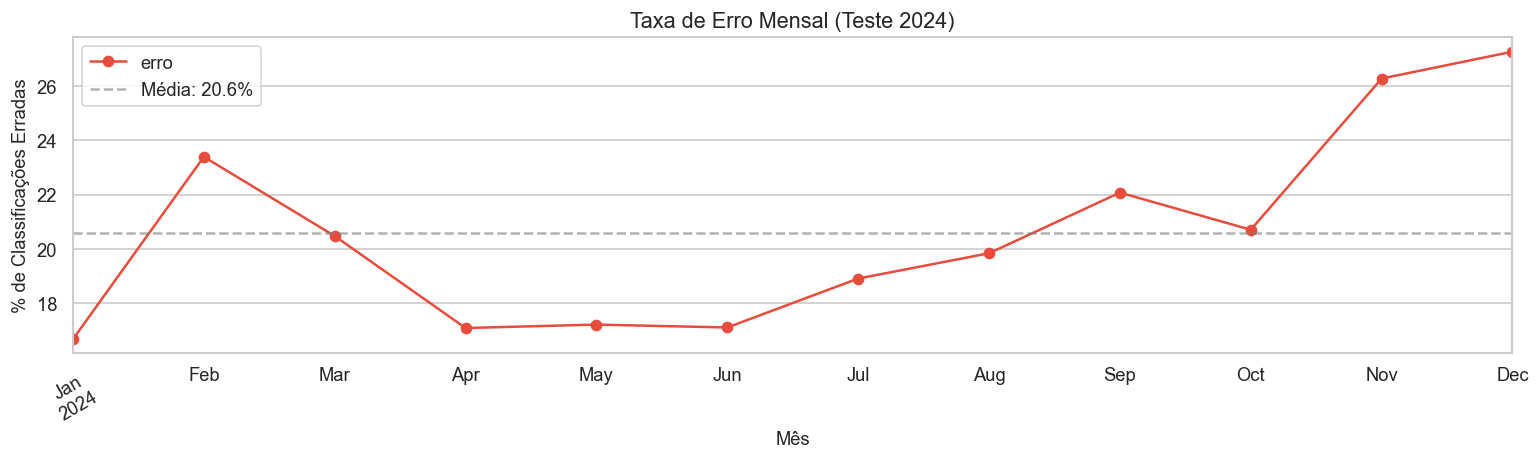

Meses com maior taxa de erro:


,Taxa Erro (%)
mes,
2024-12,27.26
2024-11,26.27
2024-02,23.39


In [112]:
df_erros = X_test.copy()
df_erros["y_real"]    = y_test.values
df_erros["y_pred"]    = y_test_pred
df_erros["y_proba"]   = y_test_proba
df_erros["erro"]      = (df_erros["y_real"] != df_erros["y_pred"]).astype(int)
df_erros["data_inicio"] = df_final.loc[mask_teste, "data_inicio"].values
df_erros["mes"]       = pd.to_datetime(df_erros["data_inicio"]).dt.to_period("M")

taxa_erro_mes = df_erros.groupby("mes")["erro"].mean() * 100

fig, ax = plt.subplots(figsize=(13, 4))
taxa_erro_mes.plot(ax=ax, marker="o", color="#e74c3c", linewidth=1.5)
ax.axhline(taxa_erro_mes.mean(), color="gray", linestyle="--", alpha=0.6,
           label=f"Média: {taxa_erro_mes.mean():.1f}%")
ax.set_title("Taxa de Erro Mensal (Teste 2024)")
ax.set_xlabel("Mês")
ax.set_ylabel("% de Classificações Erradas")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("Meses com maior taxa de erro:")
display(taxa_erro_mes.sort_values(ascending=False).head(3).to_frame("Taxa Erro (%)").round(2))

O modelo apresenta um padrão sazonal claro de erro ao longo de 2024. A performance é melhor no início do ano (janeiro ~16%) e especialmente no segundo trimestre (abril–junho, ~16–17%), que corresponde ao período de menor instabilidade climática no Rio. O erro cresce progressivamente no segundo semestre, atingindo o pico em dezembro (~27%). Esse comportamento é consistente com o verão carioca: o modelo foi treinado em 2023 e, ao encontrar em 2024 um padrão climático de fim de ano ligeiramente diferente (distribuição de chuvas, ondas de calor), perde precisão justamente onde o ambiente é mais volátil. O pico de fevereiro (~23%) reforça essa hipótese — é o mês de maior precipitação histórica no Rio, e eventos extremos são por natureza difíceis de prever com base em médias históricas. **A implicação prática é que o modelo deve ser re-treinado periodicamente com dados mais recentes**, especialmente antes do verão.

### 8.2 Erros por Dimensão Territorial

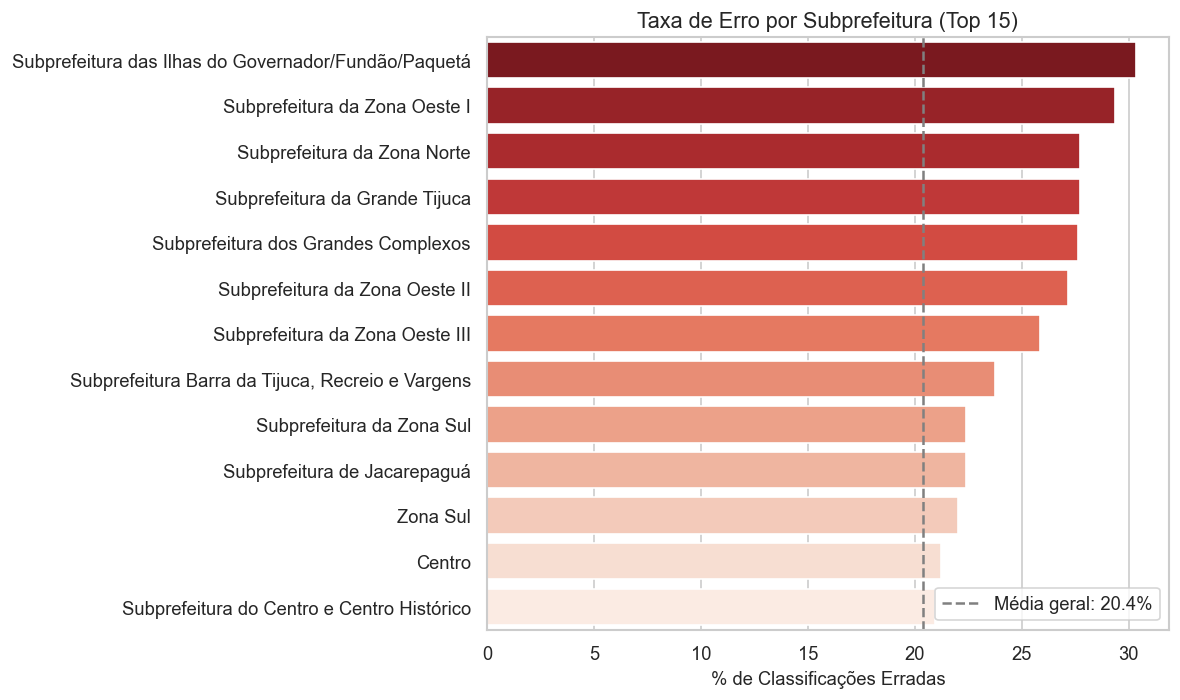

In [113]:
df_erros["subprefeitura_orig"] = df_final.loc[mask_teste, "subprefeitura"].values

erro_por_subpref = (
    df_erros.groupby("subprefeitura_orig")
    .agg(taxa_erro=("erro", "mean"), volume=("erro", "count"))
    .query("volume >= 50")  # mínimo de 50 casos para estabilidade
    .sort_values("taxa_erro", ascending=False)
    .head(15)
    .reset_index()
)
erro_por_subpref["taxa_erro"] *= 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=erro_por_subpref, y="subprefeitura_orig", x="taxa_erro",
    palette="Reds_r", ax=ax,
)
ax.axvline(df_erros["erro"].mean() * 100, color="gray", linestyle="--",
           label=f"Média geral: {df_erros['erro'].mean()*100:.1f}%")
ax.set_title("Taxa de Erro por Subprefeitura (Top 15)")
ax.set_xlabel("% de Classificações Erradas")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

A distribuição territorial dos erros revela um padrão de **desigualdade operacional**. As subprefeituras com maior taxa de erro — Ilhas do Governador/Fundão/Paquetá, Zona Oeste I, Grandes Complexos e Zona Norte — são exatamente as que a análise geoespacial da Parte 2 identificou como tendo maior tempo mediano de resolução e menor previsibilidade de demanda. O modelo erra mais onde a operação é mais irregular, o que é esperado: padrões mais caóticos produzem sinais mais fracos para o aprendizado. A Subprefeitura das Ilhas, em particular, tem dinâmica logística única (acesso por balsa, equipes reduzidas) que dificilmente é capturada pelas features atuais. Já as subprefeituras do Centro e Zona Sul aparecem no limite inferior do ranking — onde a operação é mais padronizada, o modelo acerta mais.

### 8.3 Erros por Dimensão Categórica

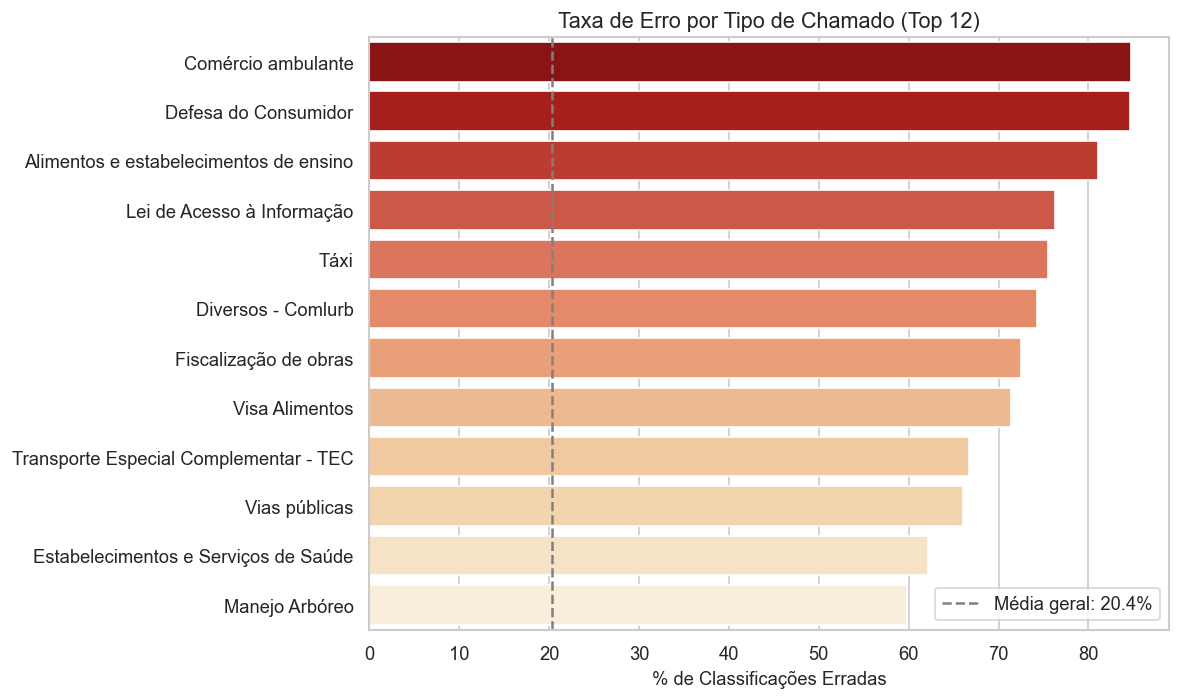

Distribuição de erros por tipo (Falso Negativo = atraso não detectado):


,Falsos Negativos
tipo_orig,
Remoção Gratuita,824
Manejo Arbóreo,496
Drenagem e Saneamento,420
Pavimentação,395
Limpeza de logradouros,368
Fiscalização de obras,177
Comércio ambulante,144
Perturbação do sossego,133
Vias públicas,133


In [114]:
df_erros["tipo_orig"]      = df_final.loc[mask_teste, "tipo"].values
df_erros["categoria_orig"] = df_final.loc[mask_teste, "categoria"].values

erro_por_tipo = (
    df_erros.groupby("tipo_orig")
    .agg(taxa_erro=("erro", "mean"), volume=("erro", "count"))
    .query("volume >= 30")
    .sort_values("taxa_erro", ascending=False)
    .head(12)
    .reset_index()
)
erro_por_tipo["taxa_erro"] *= 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=erro_por_tipo, y="tipo_orig", x="taxa_erro",
    palette="OrRd_r", ax=ax,
)
ax.axvline(df_erros["erro"].mean() * 100, color="gray", linestyle="--",
           label=f"Média geral: {df_erros['erro'].mean()*100:.1f}%")
ax.set_title("Taxa de Erro por Tipo de Chamado (Top 12)")
ax.set_xlabel("% de Classificações Erradas")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

print("Distribuição de erros por tipo (Falso Negativo = atraso não detectado):")
df_fn = df_erros[(df_erros["y_real"] == 0) & (df_erros["y_pred"] == 1)]
display(
    df_fn["tipo_orig"].value_counts().head(10).to_frame("Falsos Negativos")
)

É possível ver no gráfico acima que os tipos com maior taxa de erro — Defesa do Consumidor (~83%), Comércio Ambulante (~83%), Alimentos e Estabelecimentos de Ensino (~81%), Lei de Acesso à Informação (~76%) — têm em comum o fato de serem chamados de natureza burocrático-administrativa ou regulatória, não operacional.

A tabela de falsos negativos — casos em que o modelo previu resolução no prazo, mas o chamado atrasou — mostra que "Remoção Gratuita" lidera com 827 casos, um número expressivo que se explica pela natureza do serviço: depende de agendamento de veículo pesado, disponibilidade de equipe e, muitas vezes, confirmação do solicitante. É um serviço com alta variabilidade de execução que o modelo tende a subestimar por ser frequentemente resolvido no prazo em condições normais.

## 9. Resumo: O que o Modelo Revela para a Gestão

**1. O gargalo operacional é mais previsível do que parece**

O número de chamados já abertos na unidade responsável é o maior preditor individual de atraso. Isso significa que o acúmulo é detectável antes de virar problema: unidades que ultrapassam determinado limiar de chamados abertos devem ser priorizadas para reforço de equipe com antecedência, em vez de reagir ao atraso depois que ele já ocorreu.

**2. O clima da semana seguinte importa tanto quanto o do dia**

A chuva prevista para os próximos 7 dias aparece entre os principais fatores do modelo — e não a chuva do dia de abertura. Semanas com previsão de chuva intensa devem acionar redistribuição preventiva de equipes de campo, especialmente nas subprefeituras da Zona Oeste e Zona Norte, que combinam maior exposição climática com menor previsibilidade operacional.

**3. Tratar todos os chamados com o mesmo prazo é uma ficção**

Estacionamento Irregular e Iluminação Pública têm padrão de resolução rápido e estável. Remoção Gratuita, Manejo Arbóreo e Fiscalização de Obras são estruturalmente mais lentos e mais difíceis de prever. Monitorá-los com o mesmo prazo de referência mascara problemas reais e distorce qualquer indicador de eficiência.

**4. Onde o modelo mais erra é onde a gestão mais precisa olhar**

As subprefeituras com maior taxa de erro e os tipos com mais falsos negativos não são apenas limitações do modelo — são sinais de que a operação nessas áreas é menos padronizada e menos previsível. Chamados de Remoção Gratuita, Drenagem e Manejo Arbóreo que ultrapassem 5 dias sem movimentação merecem atenção manual independentemente do que o modelo previu.

**5. O modelo é uma ferramenta de triagem, não de substituição do gestor**

A recomendação é integrá-lo ao sistema de abertura de chamados como uma flag de risco, deixando a decisão de alocação de recursos para quem conhece o contexto local. Um modelo que o gestor não confia e não questiona é mais perigoso do que nenhum modelo.

In [126]:
# salvando modelo e dados para próxima etapa

import joblib

# Modelo
joblib.dump(pipeline_final, "../data/pipeline_final.pkl")

# Dados de teste com probabilidades
df_teste_export = df_final[mask_teste].copy()
df_teste_export["y_proba"] = y_test_proba
df_teste_export["y_pred"]  = y_test_pred
df_teste_export["y_real"]  = y_test.values

# Converter colunas de data para evitar erro de tipo dbdate no parquet
for col in ["data_inicio", "data_fim", "data_particao"]:
    if col in df_teste_export.columns:
        df_teste_export[col] = pd.to_datetime(df_teste_export[col], errors="coerce")

df_teste_export.to_parquet("../data/df_teste_com_predicoes.parquet", index=False)

print("Salvo com sucesso.")

Salvo com sucesso.
